In [143]:
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.preprocessing import StandardScaler

In [144]:
data = pd.read_csv("TrainingWiDS2021.csv")

In [145]:
data

,Unnamed: 0,encounter_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,...,h1_pao2fio2ratio_max,h1_pao2fio2ratio_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus
0,1,214826,118,68.0,22.732803,0,Caucasian,M,180.3,Floor,...,NaN,NaN,0,0,0,0,0,0,0,1
1,2,246060,81,77.0,27.421875,0,Caucasian,F,160.0,Floor,...,51.0,51.0,0,0,0,0,0,0,0,1
2,3,276985,118,25.0,31.952749,0,Caucasian,F,172.7,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0
3,4,262220,118,81.0,22.635548,1,Caucasian,F,165.1,Operating Room,...,337.0,337.0,0,0,0,0,0,0,0,0
4,5,201746,33,19.0,NaN,0,Caucasian,M,188.0,NaN,...,NaN,NaN,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130152,130153,164758,7,50.0,29.287256,0,Caucasian,M,175.3,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0
130153,130154,197653,7,79.0,29.653433,0,Caucasian,F,162.6,Direct Admit,...,NaN,NaN,0,0,0,0,0,0,0,0
130154,130155,219719,7,73.0,32.265371,0,African American,M,177.8,Emergency Department,...,163.0,163.0,0,0,0,0,0,0,0,1
130155,130156,222562,170,81.0,24.408579,0,Caucasian,M,185.4,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0


In [146]:
data.columns.tolist()

['Unnamed: 0',
 'encounter_id',
 'hospital_id',
 'age',
 'bmi',
 'elective_surgery',
 'ethnicity',
 'gender',
 'height',
 'hospital_admit_source',
 'icu_admit_source',
 'icu_id',
 'icu_stay_type',
 'icu_type',
 'pre_icu_los_days',
 'readmission_status',
 'weight',
 'albumin_apache',
 'apache_2_diagnosis',
 'apache_3j_diagnosis',
 'apache_post_operative',
 'arf_apache',
 'bilirubin_apache',
 'bun_apache',
 'creatinine_apache',
 'fio2_apache',
 'gcs_eyes_apache',
 'gcs_motor_apache',
 'gcs_unable_apache',
 'gcs_verbal_apache',
 'glucose_apache',
 'heart_rate_apache',
 'hematocrit_apache',
 'intubated_apache',
 'map_apache',
 'paco2_apache',
 'paco2_for_ph_apache',
 'pao2_apache',
 'ph_apache',
 'resprate_apache',
 'sodium_apache',
 'temp_apache',
 'urineoutput_apache',
 'ventilated_apache',
 'wbc_apache',
 'd1_diasbp_invasive_max',
 'd1_diasbp_invasive_min',
 'd1_diasbp_max',
 'd1_diasbp_min',
 'd1_diasbp_noninvasive_max',
 'd1_diasbp_noninvasive_min',
 'd1_heartrate_max',
 'd1_heartrate

In [147]:
data.shape

(130157, 181)

In [148]:
data.isnull().sum()

Unnamed: 0                        0
encounter_id                      0
hospital_id                       0
age                            4988
bmi                            4490
                               ... 
immunosuppression                 0
leukemia                          0
lymphoma                          0
solid_tumor_with_metastasis       0
diabetes_mellitus                 0
Length: 181, dtype: int64

In [149]:
data.isna().sum()

Unnamed: 0                        0
encounter_id                      0
hospital_id                       0
age                            4988
bmi                            4490
                               ... 
immunosuppression                 0
leukemia                          0
lymphoma                          0
solid_tumor_with_metastasis       0
diabetes_mellitus                 0
Length: 181, dtype: int64

In [150]:
(data == "?").sum().tolist()

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [151]:
data.isna().sum()

Unnamed: 0                        0
encounter_id                      0
hospital_id                       0
age                            4988
bmi                            4490
                               ... 
immunosuppression                 0
leukemia                          0
lymphoma                          0
solid_tumor_with_metastasis       0
diabetes_mellitus                 0
Length: 181, dtype: int64

In [152]:
data["age"].dropna()

0         68.0
1         77.0
2         25.0
3         81.0
4         19.0
          ... 
130152    50.0
130153    79.0
130154    73.0
130155    81.0
130156    35.0
Name: age, Length: 125169, dtype: float64

In [153]:
data['age'].isnull().sum()

np.int64(4988)

In [154]:
data['age'].tolist()

[68.0,
 77.0,
 25.0,
 81.0,
 19.0,
 67.0,
 59.0,
 70.0,
 45.0,
 50.0,
 72.0,
 80.0,
 48.0,
 65.0,
 81.0,
 78.0,
 30.0,
 46.0,
 65.0,
 39.0,
 79.0,
 80.0,
 58.0,
 87.0,
 60.0,
 68.0,
 85.0,
 79.0,
 nan,
 60.0,
 76.0,
 68.0,
 30.0,
 45.0,
 53.0,
 71.0,
 71.0,
 58.0,
 85.0,
 65.0,
 82.0,
 60.0,
 87.0,
 52.0,
 60.0,
 75.0,
 64.0,
 59.0,
 55.0,
 67.0,
 75.0,
 53.0,
 73.0,
 88.0,
 84.0,
 68.0,
 62.0,
 81.0,
 55.0,
 56.0,
 85.0,
 77.0,
 38.0,
 73.0,
 59.0,
 41.0,
 70.0,
 35.0,
 54.0,
 58.0,
 48.0,
 80.0,
 nan,
 74.0,
 59.0,
 84.0,
 67.0,
 73.0,
 65.0,
 82.0,
 81.0,
 49.0,
 85.0,
 56.0,
 67.0,
 62.0,
 52.0,
 30.0,
 78.0,
 88.0,
 68.0,
 86.0,
 85.0,
 65.0,
 51.0,
 55.0,
 35.0,
 63.0,
 68.0,
 25.0,
 84.0,
 61.0,
 65.0,
 71.0,
 71.0,
 72.0,
 47.0,
 75.0,
 55.0,
 33.0,
 65.0,
 89.0,
 74.0,
 48.0,
 73.0,
 73.0,
 68.0,
 75.0,
 84.0,
 50.0,
 36.0,
 89.0,
 68.0,
 69.0,
 72.0,
 71.0,
 69.0,
 74.0,
 65.0,
 72.0,
 54.0,
 84.0,
 86.0,
 56.0,
 78.0,
 72.0,
 64.0,
 58.0,
 55.0,
 46.0,
 69.0,
 63.0,
 75.0,
 

In [155]:
data.isna().sum()

Unnamed: 0                        0
encounter_id                      0
hospital_id                       0
age                            4988
bmi                            4490
                               ... 
immunosuppression                 0
leukemia                          0
lymphoma                          0
solid_tumor_with_metastasis       0
diabetes_mellitus                 0
Length: 181, dtype: int64

In [156]:
data_clean = data.replace(['nan', 'NaN'], np.nan)

In [157]:
data_clean

,Unnamed: 0,encounter_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,...,h1_pao2fio2ratio_max,h1_pao2fio2ratio_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus
0,1,214826,118,68.0,22.732803,0,Caucasian,M,180.3,Floor,...,NaN,NaN,0,0,0,0,0,0,0,1
1,2,246060,81,77.0,27.421875,0,Caucasian,F,160.0,Floor,...,51.0,51.0,0,0,0,0,0,0,0,1
2,3,276985,118,25.0,31.952749,0,Caucasian,F,172.7,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0
3,4,262220,118,81.0,22.635548,1,Caucasian,F,165.1,Operating Room,...,337.0,337.0,0,0,0,0,0,0,0,0
4,5,201746,33,19.0,NaN,0,Caucasian,M,188.0,NaN,...,NaN,NaN,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130152,130153,164758,7,50.0,29.287256,0,Caucasian,M,175.3,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0
130153,130154,197653,7,79.0,29.653433,0,Caucasian,F,162.6,Direct Admit,...,NaN,NaN,0,0,0,0,0,0,0,0
130154,130155,219719,7,73.0,32.265371,0,African American,M,177.8,Emergency Department,...,163.0,163.0,0,0,0,0,0,0,0,1
130155,130156,222562,170,81.0,24.408579,0,Caucasian,M,185.4,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0


In [158]:
# Drop columns where more than 40% of values are missing
threshold = 0.4

# Drop coulmns with 0.4 threshold missing values
data_clean = data.dropna(thresh=len(data) * (1 - threshold), axis=1)

In [159]:
data_clean.shape

(130157, 107)

In [160]:
num_cols = data_clean.select_dtypes(include = 'number').columns


In [161]:
data_clean[num_cols] = data_clean[num_cols].fillna(data_clean[num_cols].median())

C:\Users\Anz45\AppData\Local\Temp\ipykernel_14564\4038124655.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean[num_cols] = data_clean[num_cols].fillna(data_clean[num_cols].median())


In [162]:
print(data_clean.shape)
print(data_clean.isna().sum().sum())

(130157, 107)
35091


In [163]:
data_clean.isnull().sum().tolist()


[0,
 0,
 0,
 0,
 0,
 0,
 1587,
 66,
 0,
 33198,
 240,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [164]:
(data_clean == '?').sum().tolist()

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [165]:
data_clean.isna().sum()

Unnamed: 0                     0
encounter_id                   0
hospital_id                    0
age                            0
bmi                            0
                              ..
immunosuppression              0
leukemia                       0
lymphoma                       0
solid_tumor_with_metastasis    0
diabetes_mellitus              0
Length: 107, dtype: int64

In [166]:
data_clean.isna().sum()

Unnamed: 0                     0
encounter_id                   0
hospital_id                    0
age                            0
bmi                            0
                              ..
immunosuppression              0
leukemia                       0
lymphoma                       0
solid_tumor_with_metastasis    0
diabetes_mellitus              0
Length: 107, dtype: int64

In [167]:
data_clean.head()

,Unnamed: 0,encounter_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,...,d1_wbc_max,d1_wbc_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus
0,1,214826,118,68.0,22.732803,0,Caucasian,M,180.3,Floor,...,14.1,14.1,0,0,0,0,0,0,0,1
1,2,246060,81,77.0,27.421875,0,Caucasian,F,160.0,Floor,...,23.3,12.7,0,0,0,0,0,0,0,1
2,3,276985,118,25.0,31.952749,0,Caucasian,F,172.7,Emergency Department,...,11.1,10.1,0,0,0,0,0,0,0,0
3,4,262220,118,81.0,22.635548,1,Caucasian,F,165.1,Operating Room,...,9.0,8.0,0,0,0,0,0,0,0,0
4,5,201746,33,19.0,27.564749,0,Caucasian,M,188.0,NaN,...,11.1,10.1,0,0,0,0,0,0,0,0


In [168]:
data_clean = data_clean.drop([
    'Unnamed: 0',
    'encounter_id',
    'hospital_id',
    'ethnicity',
    'gender',
    'hospital_admit_source',
    'icu_admit_source',
    'icu_id',
    'icu_type',
    'pre_icu_los_days'
], axis=1)

In [169]:
data_clean.shape

(130157, 97)

In [170]:
data_clean.dtypes.tolist()

[dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('float64'),
 dtype('O'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('flo

In [171]:
data_clean.columns.to_list()

['age',
 'bmi',
 'elective_surgery',
 'height',
 'icu_stay_type',
 'readmission_status',
 'weight',
 'apache_2_diagnosis',
 'apache_3j_diagnosis',
 'apache_post_operative',
 'arf_apache',
 'bun_apache',
 'creatinine_apache',
 'gcs_eyes_apache',
 'gcs_motor_apache',
 'gcs_unable_apache',
 'gcs_verbal_apache',
 'glucose_apache',
 'heart_rate_apache',
 'hematocrit_apache',
 'intubated_apache',
 'map_apache',
 'resprate_apache',
 'sodium_apache',
 'temp_apache',
 'ventilated_apache',
 'wbc_apache',
 'd1_diasbp_max',
 'd1_diasbp_min',
 'd1_diasbp_noninvasive_max',
 'd1_diasbp_noninvasive_min',
 'd1_heartrate_max',
 'd1_heartrate_min',
 'd1_mbp_max',
 'd1_mbp_min',
 'd1_mbp_noninvasive_max',
 'd1_mbp_noninvasive_min',
 'd1_resprate_max',
 'd1_resprate_min',
 'd1_spo2_max',
 'd1_spo2_min',
 'd1_sysbp_max',
 'd1_sysbp_min',
 'd1_sysbp_noninvasive_max',
 'd1_sysbp_noninvasive_min',
 'd1_temp_max',
 'd1_temp_min',
 'h1_diasbp_max',
 'h1_diasbp_min',
 'h1_diasbp_noninvasive_max',
 'h1_diasbp_noni

In [172]:
import matplotlib.pyplot as plt

(array([     0.,      0.,      0.,      0.,      0., 130157.,      0.,
             0.,      0.,      0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

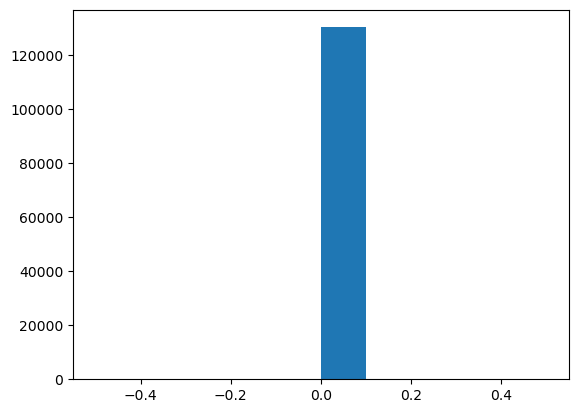

In [173]:
plt.hist(data_clean['readmission_status'])       

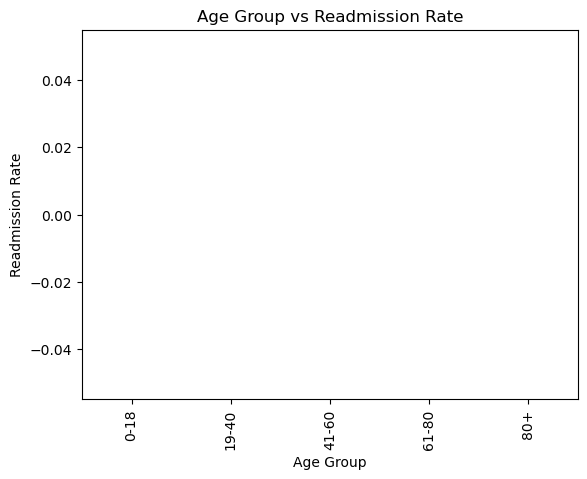

In [174]:
data_clean['age_groups'] = pd.cut(data_clean['age'], 
    bins=[0, 18, 40, 60, 80, 120],
    labels=['0-18', '19-40', '41-60', '61-80', '80+'])

readmission_rate = data_clean.groupby('age_groups', observed=False)['readmission_status'].mean()

readmission_rate.plot(kind='bar')
plt.title("Age Group vs Readmission Rate")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate")
plt.show()

In [175]:
data_clean


,age,bmi,elective_surgery,height,icu_stay_type,readmission_status,weight,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,...,d1_wbc_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus,age_groups
0,68.0,22.732803,0,180.3,admit,0,73.9,113.0,502.01,0,...,14.1,0,0,0,0,0,0,0,1,61-80
1,77.0,27.421875,0,160.0,admit,0,70.2,108.0,203.01,0,...,12.7,0,0,0,0,0,0,0,1,61-80
2,25.0,31.952749,0,172.7,admit,0,95.3,122.0,703.03,0,...,10.1,0,0,0,0,0,0,0,0,19-40
3,81.0,22.635548,1,165.1,admit,0,61.7,203.0,1206.03,1,...,8.0,0,0,0,0,0,0,0,0,80+
4,19.0,27.564749,0,188.0,admit,0,80.0,119.0,601.01,0,...,10.1,0,0,0,0,0,0,0,0,19-40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130152,50.0,29.287256,0,175.3,admit,0,90.0,110.0,104.01,0,...,10.1,0,0,0,0,0,0,0,0,41-60
130153,79.0,29.653433,0,162.6,admit,0,78.4,105.0,207.01,0,...,9.5,0,0,0,0,0,0,0,0,61-80
130154,73.0,32.265371,0,177.8,admit,0,102.0,114.0,102.01,0,...,20.4,0,0,0,0,0,0,0,1,61-80
130155,81.0,24.408579,0,185.4,admit,0,83.9,124.0,306.01,0,...,15.3,0,0,0,0,0,0,0,0,80+


In [176]:
data_clean['readmission_status'].unique()
data_clean['age'].unique()

array([68., 77., 25., 81., 19., 67., 59., 70., 45., 50., 72., 80., 48.,
       65., 78., 30., 46., 39., 79., 58., 87., 60., 85., 64., 76., 53.,
       71., 82., 52., 75., 55., 73., 88., 84., 62., 56., 38., 41., 35.,
       54., 74., 49., 86., 51., 63., 61., 47., 33., 89., 36., 69., 57.,
       22., 83., 66., 42., 27., 18., 17., 37., 43., 28., 40., 20., 32.,
       34., 23., 44., 24., 26., 31., 29., 21., 16.,  0.])

In [177]:
data_clean['readmission_status'].unique()

array([0])

In [178]:
data_clean.describe()

,age,bmi,elective_surgery,height,readmission_status,weight,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,...,d1_wbc_max,d1_wbc_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus
count,130157.000000,130157.000000,130157.000000,130157.000000,130157.0,130157.000000,130157.000000,130157.000000,130157.000000,130157.000000,...,130157.000000,130157.000000,130157.00000,130157.000000,130157.000000,130157.000000,130157.000000,130157.000000,130157.000000,130157.000000
mean,62.071936,29.056944,0.189840,169.615083,0.0,83.690237,184.670713,564.951073,0.207111,0.027997,...,12.346890,11.138070,0.00103,0.016081,0.013599,0.025669,0.007307,0.004187,0.020852,0.216285
std,16.501866,8.123902,0.392176,10.746479,0.0,24.636289,85.602060,465.132980,0.405238,0.164965,...,6.331392,5.528791,0.03207,0.125786,0.115819,0.158146,0.085166,0.064574,0.142888,0.411712
min,0.000000,14.844926,0.000000,137.200000,0.0,38.600000,101.000000,0.010000,0.000000,0.000000,...,1.200000,0.900000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,53.000000,23.737886,0.000000,162.600000,0.0,67.000000,113.000000,206.010000,0.000000,0.000000,...,8.500000,7.900000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,64.000000,27.564749,0.000000,170.100000,0.0,80.000000,122.000000,409.020000,0.000000,0.000000,...,11.100000,10.100000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,74.000000,32.546205,0.000000,177.800000,0.0,96.100000,301.000000,703.030000,0.000000,0.000000,...,14.500000,13.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,89.000000,67.814990,1.000000,195.590000,0.0,186.000000,308.000000,2201.050000,1.000000,1.000000,...,46.080000,40.898000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [179]:
data_clean.shape

(130157, 98)

In [180]:
data_clean['diabetes_mellitus'].unique()

array([1, 0])

In [181]:
data_clean['diabetes_mellitus'].value_counts()

diabetes_mellitus
0    102006
1     28151
Name: count, dtype: int64

In [182]:
data_clean['diabetes_mellitus'].value_counts(normalize=True) * 100

diabetes_mellitus
0    78.371505
1    21.628495
Name: proportion, dtype: float64

In [183]:
data_clean = data_clean.drop(['readmission_status'], axis= 1)

In [194]:
data_clean.select_dtypes(include= ['object', 'string'])

,icu_stay_type
0,admit
1,admit
2,admit
3,admit
4,admit
...,...
130152,admit
130153,admit
130154,admit
130155,admit


In [195]:
data_clean['icu_stay_type'].unique()

array(['admit', 'readmit', 'transfer'], dtype=object)

In [197]:
data_clean.head(10)

,age,bmi,elective_surgery,height,icu_stay_type,weight,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,...,d1_wbc_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus,age_groups
0,68.0,22.732803,0,180.3,admit,73.9,113.0,502.01,0,0,...,14.1,0,0,0,0,0,0,0,1,61-80
1,77.0,27.421875,0,160.0,admit,70.2,108.0,203.01,0,0,...,12.7,0,0,0,0,0,0,0,1,61-80
2,25.0,31.952749,0,172.7,admit,95.3,122.0,703.03,0,0,...,10.1,0,0,0,0,0,0,0,0,19-40
3,81.0,22.635548,1,165.1,admit,61.7,203.0,1206.03,1,0,...,8.0,0,0,0,0,0,0,0,0,80+
4,19.0,27.564749,0,188.0,admit,80.0,119.0,601.01,0,0,...,10.1,0,0,0,0,0,0,0,0,19-40
5,67.0,27.555611,0,190.5,admit,100.0,301.0,403.01,0,0,...,10.9,0,0,0,0,0,0,0,1,61-80
6,59.0,57.451002,0,165.1,admit,156.6,108.0,203.01,0,0,...,5.9,0,0,0,0,0,0,0,1,41-60
7,70.0,27.564749,0,165.0,admit,80.0,113.0,501.05,0,0,...,12.8,0,0,0,1,0,0,0,0,61-80
8,45.0,27.564749,0,170.2,admit,80.0,116.0,103.01,0,0,...,24.7,0,0,0,0,0,0,0,0,41-60
9,50.0,25.707702,0,175.3,admit,79.0,112.0,107.01,0,0,...,12.8,0,0,0,0,0,0,0,0,41-60


In [198]:
data_clean['bmi_groups'] = pd.cut(data_clean['bmi'], bins=[0, 18.5, 24.9, 29.9, 100], 
                                  labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [201]:
data_clean['bmi_groups']

0             Normal
1         Overweight
2              Obese
3             Normal
4         Overweight
             ...    
130152    Overweight
130153    Overweight
130154         Obese
130155        Normal
130156         Obese
Name: bmi_groups, Length: 130157, dtype: category
Categories (4, object): ['Underweight' < 'Normal' < 'Overweight' < 'Obese']

In [202]:
data_clean['age_groups']

0         61-80
1         61-80
2         19-40
3           80+
4         19-40
          ...  
130152    41-60
130153    61-80
130154    61-80
130155      80+
130156    19-40
Name: age_groups, Length: 130157, dtype: category
Categories (5, object): ['0-18' < '19-40' < '41-60' < '61-80' < '80+']

C:\Users\Anz45\AppData\Local\Temp\ipykernel_14564\1466983826.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diabetes_rate = data_clean.groupby('bmi_groups')['diabetes_mellitus'].mean()


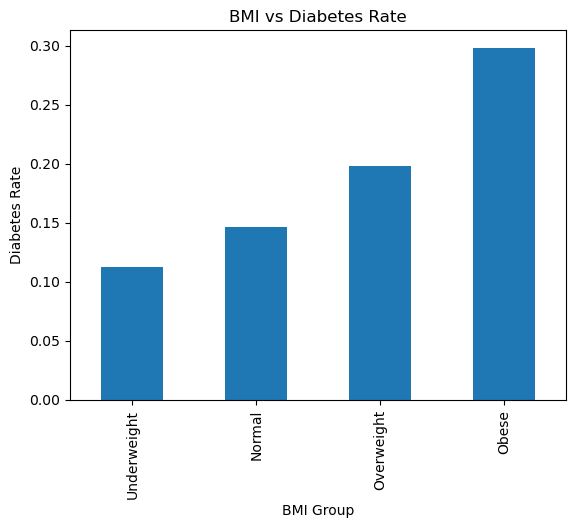

In [206]:
diabetes_rate = data_clean.groupby('bmi_groups')['diabetes_mellitus'].mean()
diabetes_rate.plot(kind = 'bar')
plt.title("BMI vs Diabetes Rate")
plt.xlabel("BMI Group")
plt.ylabel("Diabetes Rate")
plt.show()